In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import jetsimpy
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.lines import Line2D

from astropy.cosmology import Planck18 as cosmo
from scipy.integrate import quad, quad_vec

In [3]:
from modules.tools import flux_to_mag

In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [6]:
# constants and unit conversions
h = 6.62 * 1.0e-34      # Planck constant in J/Hz
c = 299792458.      # light speed in m/s
keV2J = 1e3 * 1.6e-19     # conversion keV to joules
erg2J = 1e-7        # conversion erg to joules

### Define some useful functions

In [7]:
def flux_to_mag(flux):
    """ Convert flux from milliJansky to AB Magnitude

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param flux: flux in milli-Jansky
    :return: mag: as the AB Magnitude
    """

    mag = -2.5 * np.log10(flux*1.0e-26) - 48.6
    return mag


def mag_to_flux(mag):
    """ Convert flux from AB Magnitude to milliJansky

    1 Jy = 1e-23 erg/cm2/s/Hz
    Fnu = 3631 Jy = 3.631*1e-20 erg/cm2/s/Hz
    ABmag = 0-2.5*log10( Fnu )-48.6 = 0

    :param mag: as the AB Magnitude
    :return: flux: flux in milli-Jansky
    """
    
    flux = pow(10, (26 - (mag + 48.6) / 2.5))
    return flux


## Light curves with `jetsimpy`

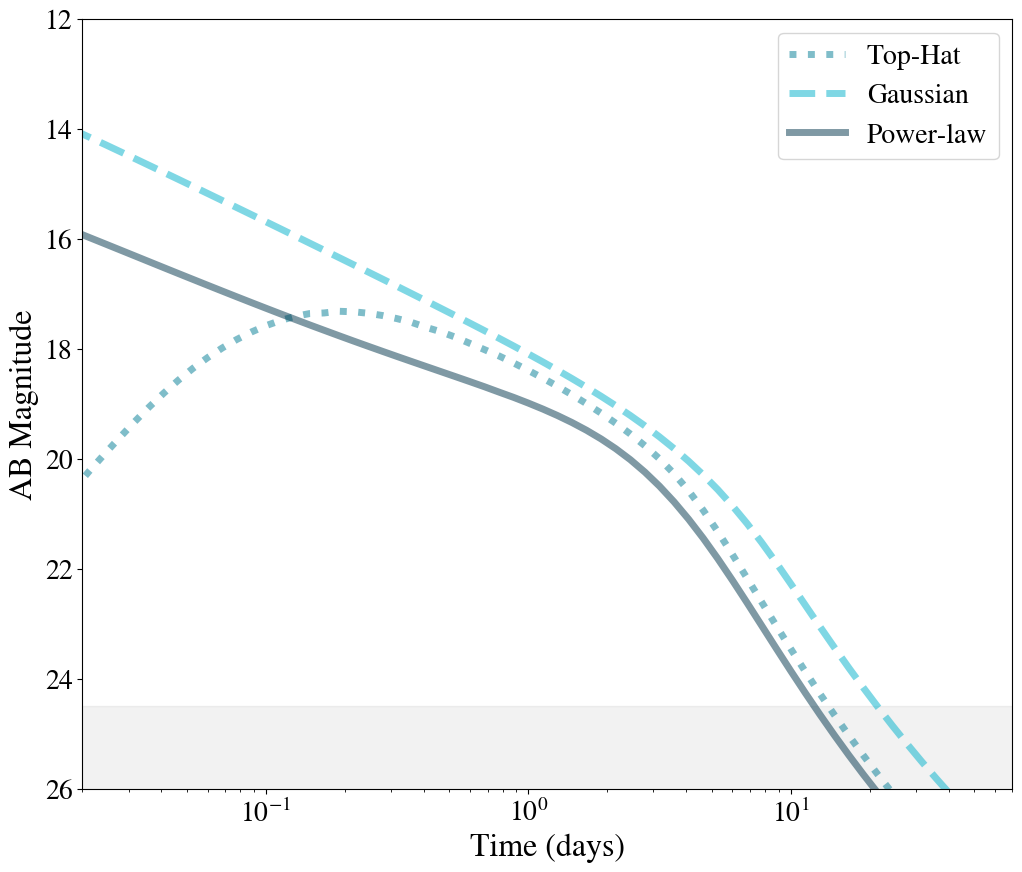

In [67]:
# put the parameters in a dictionary
P = dict(
    Eiso = 1e52,        # Core isotropic equivalent energy
    lf = 1000,           # Core Lorentz factor
    theta_c = 0.1,      # half opening angle
    n0 = 1,             # ism number density
    A = 0,              # wind number density amplitude
    eps_e = 0.1,        # epsilon_e
    eps_b = 0.01,       # epsilon_b
    p = 2.2,           # electron power index
    theta_v = 0.15,      # viewing angle (rad)
    d = 474.33,         # distance (Mpc)
    z = 0.1,            # redshift
    s = 4,              # power-law jet slope (required for power-law jet)
)

plt.rcParams.update({'font.size':20})
plt.figure(figsize=(12,10))

# define the observing time and frequency
tday = np.logspace(-3, 2.5, 100)
tsecond = tday * 3600 * 24
nu = 5e14

# flux density
mag_tophat = flux_to_mag(jetsimpy.FluxDensity_tophat(tsecond, nu, P))
mag_gaussian = flux_to_mag(jetsimpy.FluxDensity_gaussian(tsecond, nu, P))
mag_powerlaw = flux_to_mag(jetsimpy.FluxDensity_powerlaw(tsecond, nu, P))

plt.plot(tday, mag_tophat, label="Top-Hat", color='#007c95', ls=':', lw=5, alpha=0.5)
plt.plot(tday, mag_gaussian, label="Gaussian", color='#00b1cb', ls='--', lw=5, alpha=0.5)
plt.plot(tday, mag_powerlaw, label="Power-law", color='#00344b', lw=5, alpha=0.5)

plt.fill_between([1e-2, 1e3], 24.5, 31., color='k', alpha=0.05)

plt.xscale("log")
plt.gca().invert_yaxis()
plt.xlim(0.02, 70)
plt.ylim(26, 12)
plt.xlabel("Time (days)", fontsize=23)
plt.ylabel("AB Magnitude", fontsize=23)
plt.legend()

#plt.savefig('../figures/orphan_lc_th_jetsimpy.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()

## Impact of the Lorentz factor (not taken into account in `afterglowpy`)

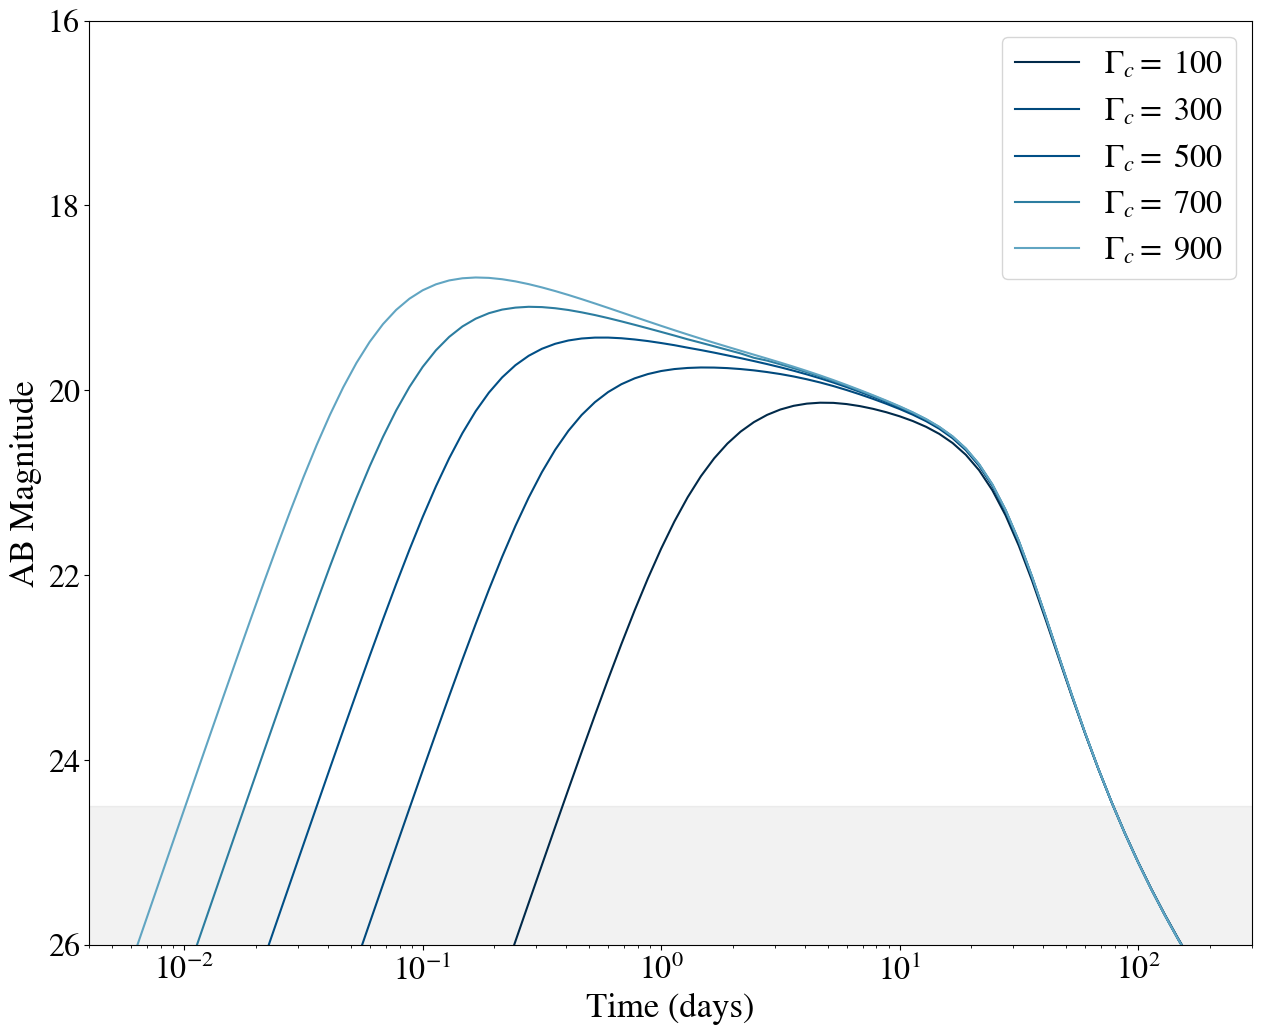

In [69]:
# put the parameters in a dictionary
P = dict(
    Eiso = 1e53,        # Core isotropic equivalent energy
    lf = 300,           # Core Lorentz factor
    theta_c = 0.1,      # half opening angle
    n0 = 1,             # ism number density
    A = 0,              # wind number density amplitude
    eps_e = 0.1,        # epsilon_e
    eps_b = 0.01,       # epsilon_b
    p = 2.2,           # electron power index
    theta_v = 0.3,      # viewing angle (rad)
    d = 474.33,         # distance (Mpc)
    z = 0.1,            # redshift
    s = 4,              # power-law jet slope (required for power-law jet)
)

plt.rcParams.update({'font.size': 23})
plt.figure(figsize=(15,12))

# define the observing time and frequency
tday = np.logspace(-3, 2.5, 100)
tsecond = tday * 3600 * 24
nu = 5e14

lambda_values = [100, 300, 500, 700, 900]

colors = ['#012a4a', '#01497c', '#014f86', '#2c7da0', '#61a5c2']

for l, c in zip(lambda_values, colors):
    P['lf'] = l
    mag_powerlaw = flux_to_mag(jetsimpy.FluxDensity_powerlaw(tsecond, nu, P))
    plt.plot(tday, mag_powerlaw, label=rf'$\Gamma_c =$ {int(l)}', color=c)

plt.fill_between([1e-3, 1e3], 24.5, 31., color='k', alpha=0.05)

plt.xscale("log")
plt.gca().invert_yaxis()
plt.xlim(0.004, 300)
plt.ylim(26, 16)
plt.xlabel("Time (days)", fontsize=25)
plt.ylabel("AB Magnitude", fontsize=25)
plt.legend()

#plt.savefig('/home/masson/afterglowpy/figures/jetsimpy_gamma_evo.pdf', format="pdf", bbox_inches="tight", transparent=True)

plt.show()

## Simulate light curves for the SBAT4-like orphan population

In [236]:
df_orphans_1 = pd.DataFrame(pd.read_pickle(f'../../orphans/data/simulations/grb_pop_jetsimpy/configs_sbat4_grb_pop_jetsimpy_40101240.pkl'))
df_orphans_2 = pd.DataFrame(pd.read_pickle(f'../../orphans/data/simulations/grb_pop_jetsimpy/configs_sbat4_grb_pop_jetsimpy_40101243.pkl'))
df_orphans_3 = pd.DataFrame(pd.read_pickle(f'../../orphans/data/simulations/grb_pop_jetsimpy/configs_sbat4_grb_pop_jetsimpy_40101244.pkl'))
df_orphans_4 = pd.DataFrame(pd.read_pickle(f'../../orphans/data/simulations/grb_pop_jetsimpy/configs_sbat4_grb_pop_jetsimpy_40101245.pkl'))

In [237]:
df_orphans = pd.concat([df_orphans_1, df_orphans_2, df_orphans_3, df_orphans_4])

In [238]:
df_orphans

,Eiso,E0,thetaCore,thetaObs,thetaWing,n,z,dL,GammaCore,Gamma,T90,Fbat
0,3.848784e+50,4.517167e+53,0.250326,1.569971,0.470592,12.127201,0.047351,6.692566e+24,652.547275,2.052918,23.999324,6.596626
1,2.162531e+51,7.829503e+53,0.238280,1.067439,0.087702,0.017622,0.075798,1.092874e+25,144.534066,1.750385,64.138101,7.506249
2,1.883846e+50,4.380931e+53,0.082190,0.620513,0.391869,1.648307,0.050463,7.148271e+24,253.526544,1.213391,32.842878,3.581178
3,1.302063e+52,6.065973e+53,0.179653,0.386718,1.354735,0.650807,0.088600,1.288622e+25,243.793076,16.529751,11.694619,20.660609
4,7.021453e+50,2.722300e+53,0.233986,1.069870,1.148044,0.011230,0.051089,7.240196e+24,331.374173,2.608387,24.240440,8.238688
...,...,...,...,...,...,...,...,...,...,...,...,...
995,3.439472e+51,4.053014e+53,0.249883,0.779500,0.700575,0.959981,0.067512,9.678480e+24,534.692660,10.772089,18.911894,7.904859
996,4.727862e+51,9.947052e+53,0.216255,0.819130,0.367993,8.499925,0.028065,3.911628e+24,268.900618,3.509188,36.248168,79.356343
997,1.402701e+51,9.203849e+53,0.172239,0.917913,1.359806,0.022959,0.035847,5.024726e+24,202.268853,1.574373,8.152077,150.113574
998,2.662215e+50,2.593817e+52,0.116304,0.338794,0.745934,4.448920,0.061892,8.838238e+24,104.992064,3.407881,11.793816,3.570461


In [240]:
# parameters in a dictionary
P = dict(
    Eiso = 1e53,                                # isotropic equivalent energy
    lf = 300,                                   # lorentz factor
    theta_c = 0.1,                              # jet half opening angle [rad]
    n0 = 1,                                     # ism number density
    A = 0,                                      # wind number density amplitude
    eps_e = 0.1,                                # epsilon_e
    eps_b = 0.01,                               # epsilon_b
    p = 2.2,                                    # electron power index
    theta_v = 0.2,                              # viewing angle [rad]
    s = 4,                                      # power-law jet slope (required for power-law jet)
    d = cosmo.luminosity_distance(0.55).value,  # distance [Mpc]
    z = 0.55,                                   # redshift
)

In [242]:
configs_lc = {'config': P,
              't_day': [],
              'mag_g': [],
             }

orphans_obs_gband = []

for i in range(len(df_orphans)):
#for i in range(10):
    P['Eiso'] = df_orphans.iloc[i]['E0']
    P['theta_c'] = df_orphans.iloc[i]['thetaCore']
    P['n0'] = df_orphans.iloc[i]['n']
    P['theta_v'] = df_orphans.iloc[i]['thetaObs']
    P['z'] = df_orphans.iloc[i]['z']
    P['d'] = cosmo.luminosity_distance(df_orphans.iloc[i]['z']).value
    P['lf'] = df_orphans.iloc[i]['GammaCore']

    jet = jetsimpy.Jet(
        jetsimpy.PowerLaw(P["theta_c"], P["Eiso"], lf0=P["lf"]),    # jet profile
        P["A"],                        # wind number density scale
        P["n0"],                       # ism number density scale
        spread=False,                  # w/wo spreading effect 
        grid=jetsimpy.ForwardJetRes(P["theta_c"], 129)  # resolution
    )


    # ---------- (step 2) calculate flux density ---------- #
    
    # define the observing time and frequency
    tday = np.logspace(-1, 4, 100)
    tsecond = tday * 3600 * 24
    nu = 629326620516047.8  # [Hz] g-band frequency in Hz
    
    # calculate the afterglow flux density [mJy]
    flux = jet.FluxDensity(
        tsecond,           # [second] observing time span
        nu,                # [Hz] observing frequency
        P,                 # parameter dictionary
    )
    
    mag = flux_to_mag(flux)

    if min(mag) < 24.5 and P['theta_v'] > P['theta_c']:

        configs_lc['config'] = P.copy()
        configs_lc['t_day'] = tday
        configs_lc['mag_g'] = mag

        orphans_obs_gband.append(configs_lc.copy())

        """
        # plot the light curves
        plt.plot(tday, mag, color='k')
        plt.gca().invert_yaxis()
        #plt.ylim(30, 15)
        plt.xscale('log')
        plt.xlabel('Time (days)')
        plt.ylabel('AB Magnitude')
        
        plt.show()"""

In [250]:
len(orphans_obs_gband)

3228

### Open configurations

`df_pop_sbat4` is the population of GRBs that was created based on the SBAT4 catalogue. We need to generate the corresponding afterglow light curves with the model implemented in the `jetsimpy` package and to keep the ones with a flux in X-ray (that would be detected by Fermi GBM) lower than 0.5 ph/s/cm², but also a flux in the g-band lower than 24.5 (Rubin nightly limiting magnitude).

In [244]:
def X_flux(nu, tmax, P):
    """ Flux for an array of frequency but one value of t
    """

    jet = jetsimpy.Jet(
        jetsimpy.PowerLaw(P["theta_c"], P["Eiso"], lf0=P["lf"]),    # jet profile
        P["A"],                        # wind number density scale
        P["n0"],                       # ism number density scale
        spread=False,                  # w/wo spreading effect 
        grid=jetsimpy.ForwardJetRes(P["theta_c"], 129)  # resolution
    ) 
    
     # calculate the afterglow flux density [mJy]
    Fnu = jet.FluxDensity(
        tmax,           # [second] observing time span
        nu,                # [Hz] observing frequency
        P,                 # parameter dictionary
    ) * 1e-29   # flux in J/m2/s/Hz
    
    Fphot = np.array(Fnu) / (h*nu)  # photon flux
    return Fphot


def time_flux_max(P, nu_X=100 * keV2J / h):
    """Compute and return the time of the max flux value in the X band
    """
    
    st = np.geomspace(1.0e-2, 100, 20)  # time in days

    # print("call fluxDensity with n=", n)
    jet = jetsimpy.Jet(
        jetsimpy.PowerLaw(P["theta_c"], P["Eiso"], lf0=P["lf"]),    # jet profile
        P["A"],                        # wind number density scale
        P["n0"],                       # ism number density scale
        spread=False,                  # w/wo spreading effect 
        grid=jetsimpy.ForwardJetRes(P["theta_c"], 129)  # resolution
    ) 
    
     # calculate the afterglow flux density [mJy]
    Fnu = jet.FluxDensity(
        st,           # [second] observing time span
        nu,                # [Hz] observing frequency
        P,                 # parameter dictionary
    ) * 1e-29   # flux in J/m2/s/Hz
    
    # return the time of the max Flux value in the X band
    imax = np.argmax(Fnu)
    return st[imax]


def X_fluence_max(P):
    """Integrate flux on the whole frequency channel of the Fermi GBM instrument
    """
    tFmax = time_flux_max(P)
    Fgbm, err = quad(X_flux, nu_min_gbm, nu_max_gbm, args=(tFmax, P))
    return Fgbm * 1e-4

In [248]:
nu_min_gbm = 50. * keV2J / h
nu_max_gbm = 300. * keV2J / h

Fgbm_list = []

for i in range(len(orphans_obs_gband)):

    P = orphans_obs_gband[i]['config']
    Fgbm = X_fluence_max(P)
    Fgbm_list.append(Fgbm)   # in ph/cm2/s

In [255]:
orphans_obs_g_x = np.array(orphans_obs_gband)[np.where(np.array(Fgbm_list) < 0.5)[0]]

### Generate pseudo-observations of the orphan afterglow population

In [140]:
import os

In [142]:
import sqlite3

from astropy.time import Time, TimeDelta
from astropy.coordinates import SkyCoord

from rubin_sim.photUtils.Bandpass import Bandpass
from rubin_sim.photUtils.Sed import Sed
from rubin_sim.data import get_baseline

from modules.tools import obs_duration_th, time_coord, flux_to_mag
from modules.functions_pseudo_obs import compute_mags, df_obs, real_obs, grb_obs_duration

In [221]:
baseline_db = get_baseline()
print(baseline_db)

conn = sqlite3.connect(baseline_db)

# In the near future, 'summaryallprops' will be replaced with 'observations'
df = pd.read_sql('select * from observations;', conn)

conn.close()

path_rubin_sim_data = '/home/masson/rubin_sim_data'
fdir = os.path.join(path_rubin_sim_data, 'throughputs', 'baseline')

# Read the throughput curves
filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}

lsst = {}
for f in filterlist:
    lsst[f] = Bandpass()
    lsst[f].readThroughput(os.path.join(fdir, f'total_{f}.dat'))

all_LC = []

for i in range(10):
    
    # dictionary containing all the GRB information
    LC = {'config': {},  # Dictionary P
          'grb_time': 0,  # GRB observation date
          'grb_coord': 0,  # GRB ra/dec coordinates
          'time': [],  # Time of each detection
          'mags': [],  # Magnitude of the detection
          'filt': [],  # Filter used at the moment of the detection
          'mags_lim': [],  # Limiting magnitude of the detection at the observation time
          'mags_err': []}   # Error on the magnitude
    

    config = orphans_obs_gband[i]['config']
    
    # Time in mjd and ra/dec coordinates of the GRB
    grb_time, grb_coord = time_coord()

    # Observe t_before days before and t_after days after
    t_before = TimeDelta(20, format='jd')
    t_after = TimeDelta(365, format='jd')
    obs_start = grb_time - t_before
    obs_end = grb_time + t_after

    # Get time span
    df_time = df[(df['observationStartMJD'] > obs_start.mjd) & (df['observationStartMJD'] < obs_end.mjd)]

    # Angular separation with SkyCoord.separation
    # Rubin FOV is 47 square degree for a 3.5-degree diameter, hence 1.7 deg separation radius.
    df_time['Separation'] = SkyCoord(df_time['fieldRA'], df_time['fieldDec'], unit="deg").separation(grb_coord).degree
    df_sky = df_time[df_time['Separation'] < 1.7]

    time_bins = grb_obs_duration(df_sky, grb_time)

    obs_list = df_obs(config, df_sky, time_bins, lsst)

    y_mags = []    # magnitude with extinction

    # If there is no observation, let's go to the next configuration
    if len(obs_list) == 0:
        all_LC.append(0)
        continue

    else:
        obs_df = pd.concat(obs_list)

        obs_df['observationId'] = df_sky['observationId']

        x_times, y_mags_without_ext, z_colors, mags_lim, mags_err = real_obs(obs_df, df_sky, time_bins, grb_time, lsst)

        LC['mags'] = y_mags_without_ext
        LC['config'] = config
        LC['grb_time'] = grb_time.isot
        LC['grb_coord'] = grb_coord.to_string('hmsdms')
        LC['time'] = x_times
        LC['filt'] = z_colors
        LC['mags_lim'] = mags_lim
        LC['mags_err'] = list(np.array(mags_err)[:, 0, 0])

        all_LC.append(LC.copy())

#print(all_LC)

#file = open(f'/home/masson/jetsimpy/orphan_pop/data/pseudo_obs_jetsimpy_test.pkl', 'wb')
#pickle.dump(all_LC, file)
#file.close()

/home/masson/rubin_sim_data/sim_baseline/baseline_v2.1_10yrs.db
[{'config': {'Eiso': np.float64(4.517167111058017e+53), 'lf': np.float64(652.5472750862241), 'theta_c': np.float64(0.25032618401695506), 'n0': np.float64(12.127200609213142), 'A': 0, 'eps_e': 0.1, 'eps_b': 0.01, 'p': 2.2, 'theta_v': np.float64(1.5699713897277041), 's': 4, 'd': np.float64(217.29110644674137), 'z': np.float64(0.047351113399230024)}, 'grb_time': '2029-10-07T08:55:47.742', 'grb_coord': '11h09m17.83665319s -47d53m29.95478927s', 'time': [np.float64(62490.29076009264), np.float64(62490.30927771124), np.float64(62492.292837433626), np.float64(62492.32180006928), np.float64(62492.33682979085), np.float64(62492.348109726154), np.float64(62503.28673612313), np.float64(62503.30674573578), np.float64(62510.35205119595), np.float64(62510.36318220337), np.float64(62521.280153181884), np.float64(62521.28060002965), np.float64(62521.30450108969), np.float64(62521.30494964704), np.float64(62535.23335101751), np.float64(6253

### Plot

In [222]:
file_open = open('data/pseudo_obs_jetsimpy_test.pkl', 'rb')
oa_jetsimpy = pickle.load(file_open)
file_open.close()

In [223]:
def plot_pseudo_obs(lc, lc_th=True):

    """ Plot pseudo-observed light curve of an afterglow

    :param lc: dictionary containing the pseudo-observed light curve, calculated with the generate_pseudo_obs function (in the pickling module)
    :param path_dustmaps: path of the directory where you the conversion table is saved
    :param flux: whether you want to plot the flux in magnitude or in mJy. Takes the values 'mag' or 'flux', default is 'mag'
    :param extinction: whether you want to consider the galactic extinction. Takes the values 'True' or 'False', default is 'True'

    :return: plot of the afterglow pseudo-observed light curve
    """

    plt.rcParams.update({'font.size': 18})
    plt.figure(figsize=(10,8))

    filterlist = ['u', 'g', 'r', 'i', 'z', 'y']
    filtercolors = {'u': 'b', 'g': 'c', 'r': 'g', 'i': 'orange', 'z': 'r', 'y': 'm'}
    all_nu = [840336134453781.4, 629326620516047.8, 482703137570394.2, 397614314115308.1, 344530577088716.56, 298760145396604.1]

    P = lc['config']
    
    x_times = lc['time']
    z_colors = lc['filt']

    y_mags = lc['mags']
    mags_lim = lc['mags_lim']
    mags_err = lc['mags_err']
    plt.gca().invert_yaxis()
    plt.ylabel('AB Magnitude', fontsize=20)

    if lc_th == True:
        
        t_min = np.min(np.array(x_times)[np.array(y_mags) < np.array(mags_lim)])
        t_max = np.max(np.array(x_times)[np.array(y_mags) < np.array(mags_lim)])
        t_th = np.linspace(t_min-Time(lc['grb_time']).mjd, t_max-Time(lc['grb_time']).mjd, num=100)

        for nu in all_nu:
            
            jet = jetsimpy.Jet(
                jetsimpy.PowerLaw(P["theta_c"], P["Eiso"], lf0=P["lf"]),    # jet profile
                P["A"],                        # wind number density scale
                P["n0"],                       # ism number density scale
                spread=False,                  # w/wo spreading effect 
                grid=jetsimpy.ForwardJetRes(P["theta_c"], 129)  # resolution
            )
            
            # calculate the afterglow flux density (unit: mJy)
            fnu = jet.FluxDensity(
                t_th*3600*24,      # [second] observing time span
                nu,                # [Hz]     observing frequency
                P,                 # parameter dictionary
            )

            mag = flux_to_mag(fnu)
            if nu == all_nu[0]:
                plt.plot(t_th+Time(lc['grb_time']).mjd, mag, color=filtercolors[filterlist[all_nu.index(nu)]], alpha=0.3, label='model')
            else:
                plt.plot(t_th+Time(lc['grb_time']).mjd, mag, color=filtercolors[filterlist[all_nu.index(nu)]], alpha=0.3)

    # plot pseudo observed light curve
    for x, y, z, m, e in zip(x_times, y_mags, z_colors, mags_lim, mags_err):
        if y < m:
            plt.scatter(x, y, c=z, s=20)
            plt.errorbar(x, y, e, c=z, capsize=0)
            plt.scatter(x, m, c=z, marker='2', s=60)

    #plt.title('Pseudo observed light curve', fontsize=28)
    plt.xlabel('Time (MJD)', fontsize=20)

    legend_elements_2 = list()

    for filt in filterlist:
        fcolor = filtercolors[filt]
        legend_elements_2.append(Line2D([0], [0], marker='o', color=fcolor, label=filt,
                                        markerfacecolor=fcolor, markersize=5))
    plt.legend(handles=legend_elements_2)
    
    plt.show()

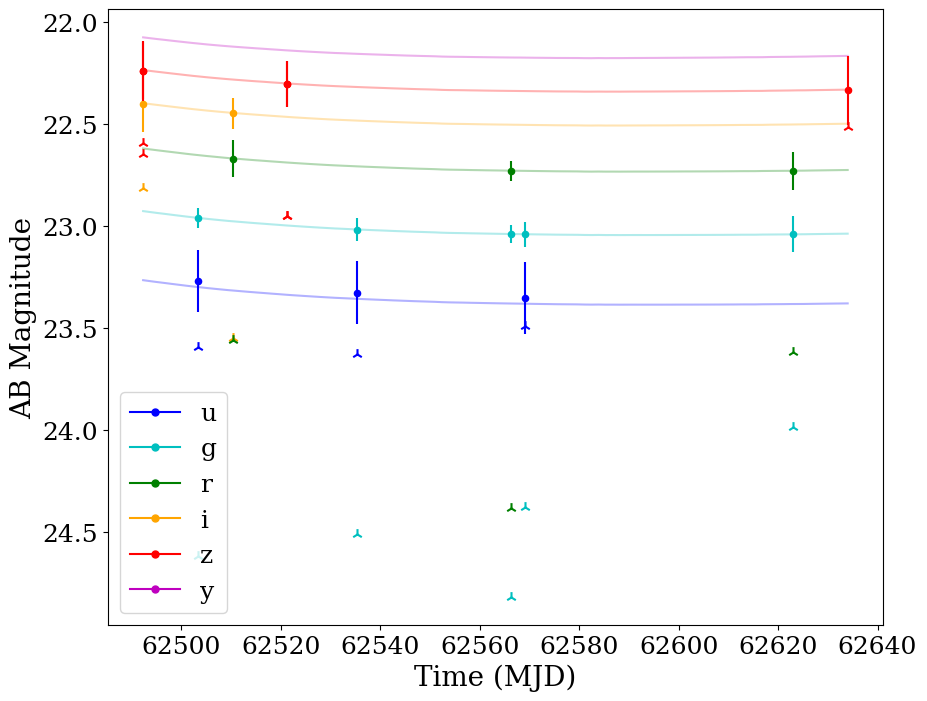

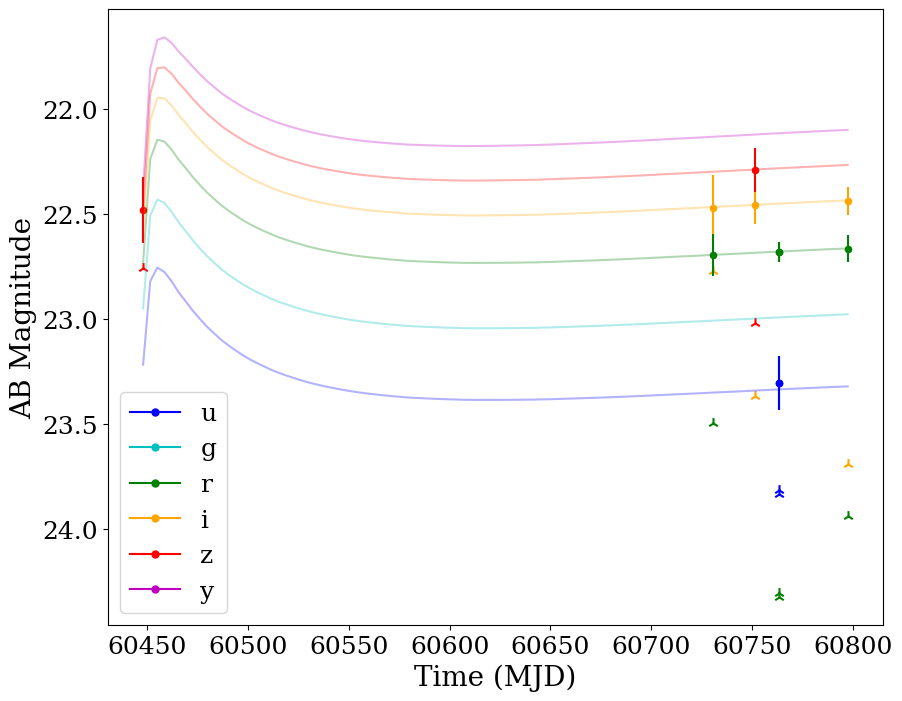

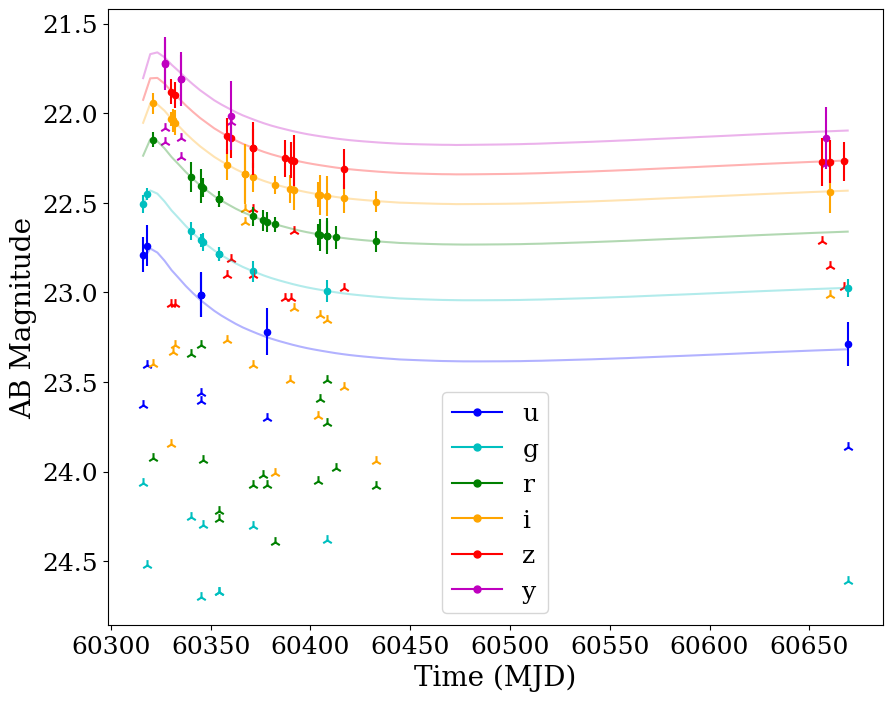

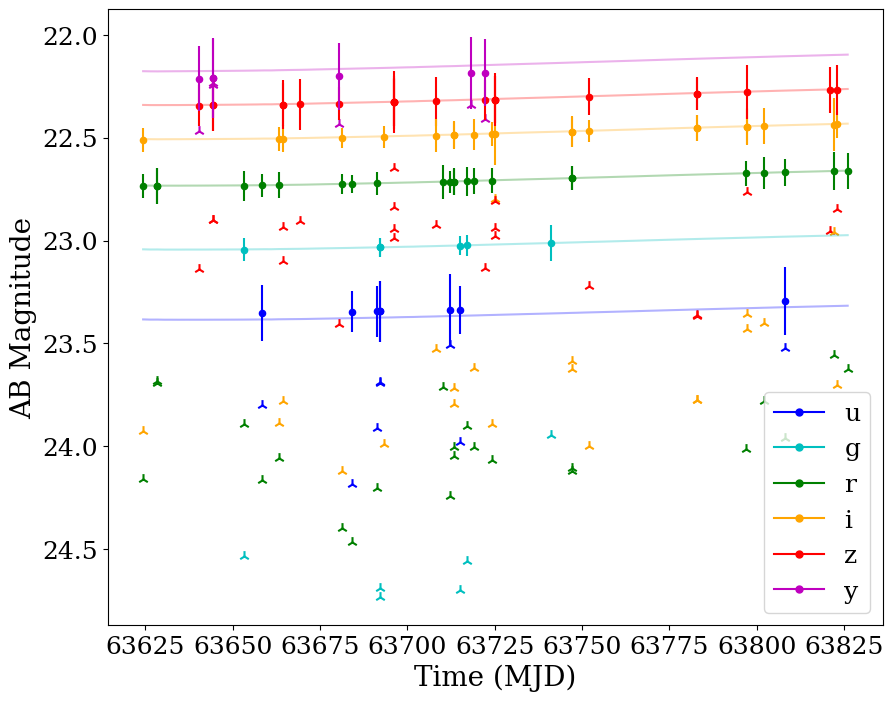

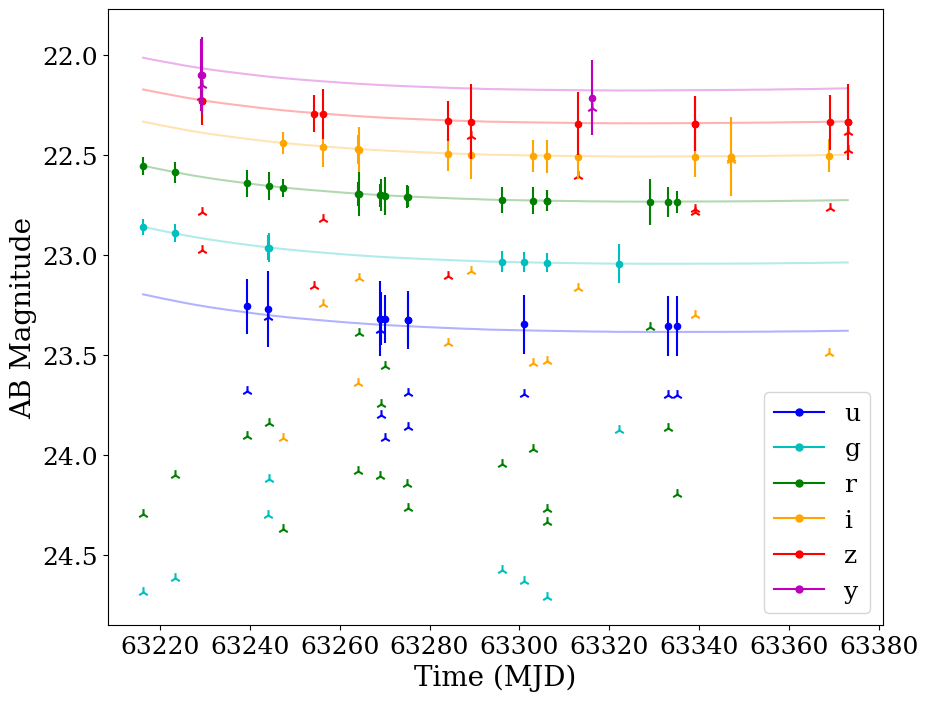

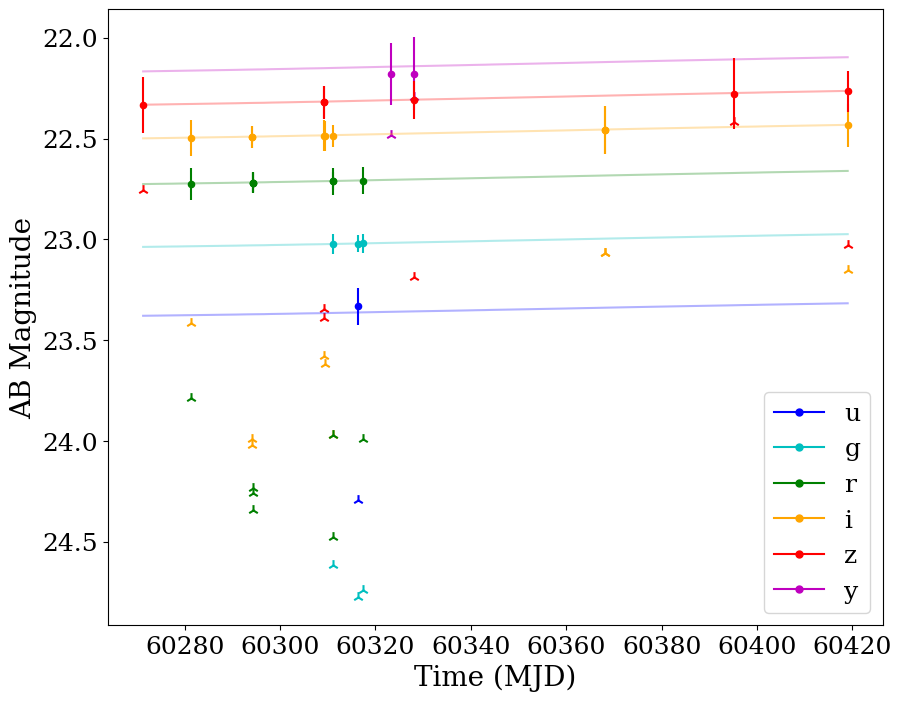

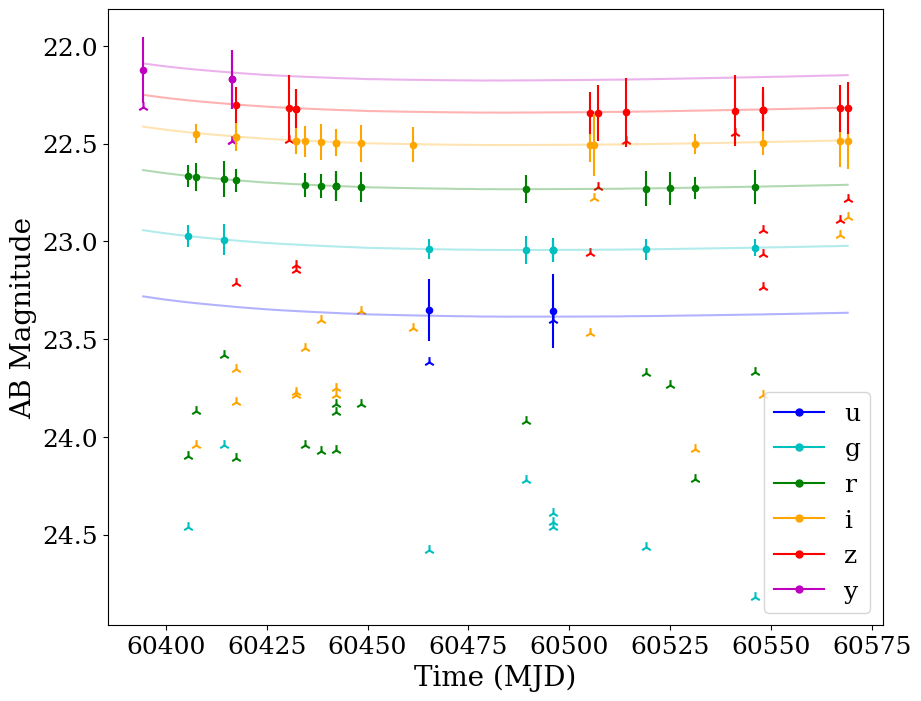

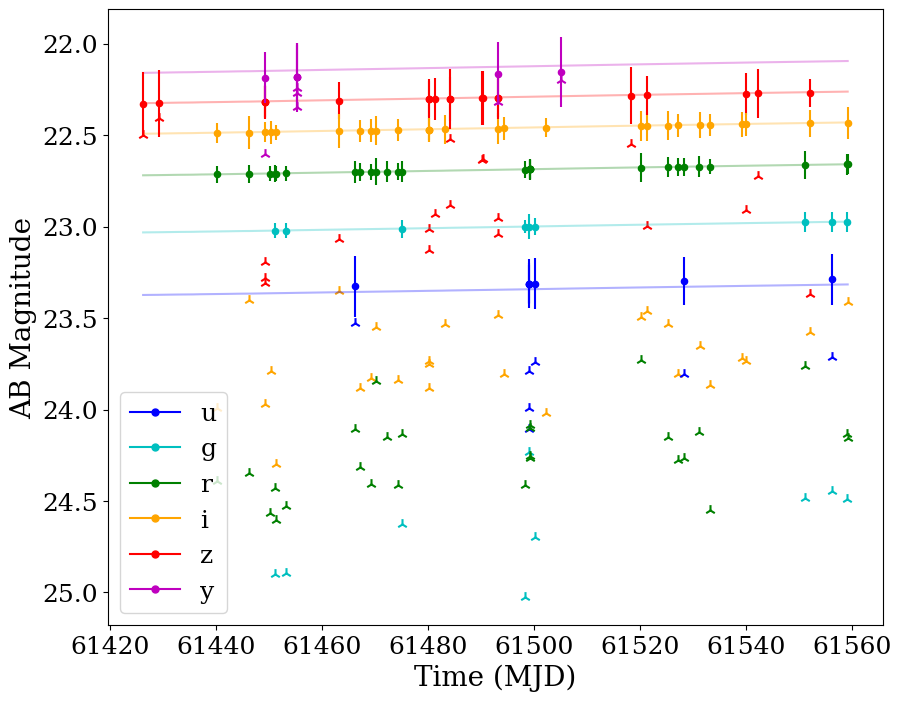

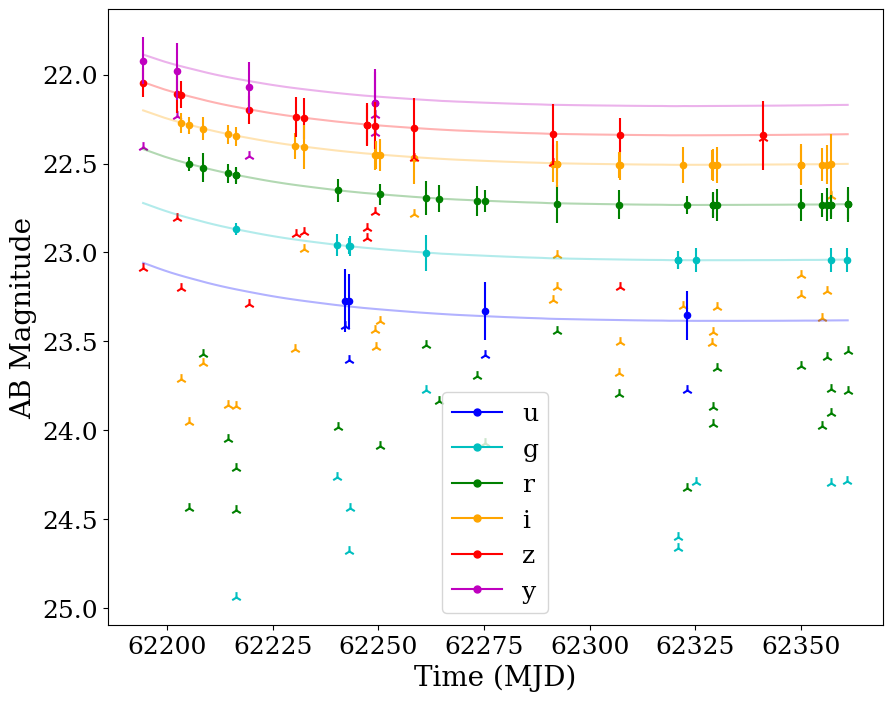

In [225]:
oa_jetsimpy_5pts = []

for i in range(len(oa_jetsimpy)):
    if len(np.array(oa_jetsimpy[i]['mags'])[np.array(oa_jetsimpy[i]['mags']) < np.array(oa_jetsimpy[i]['mags_lim'])]) > 5:
        oa_jetsimpy_5pts.append(oa_jetsimpy[i])
        plot_pseudo_obs(oa_jetsimpy[i])